In [1]:
!pip install numpy pandas matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

position_level = np.array([1,2,3,4,5,6,7,8,9,10])
salary = np.array([45000,50000,60000,80000,110000,150000,200000,300000,500000,1000000])

dataset = pd.DataFrame({"Position_Level": position_level, "Salary": salary})

dataset

,Position_Level,Salary
0,1,45000
1,2,50000
2,3,60000
3,4,80000
4,5,110000
5,6,150000
6,7,200000
7,8,300000
8,9,500000
9,10,1000000


In [3]:
X = dataset[["Position_Level"]].values
y = dataset["Salary"].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Missing values in X:", np.isnan(X).sum())
print("Missing values in y:", np.isnan(y).sum())

X shape: (10, 1)
y shape: (10,)
Missing values in X: 0
Missing values in y: 0


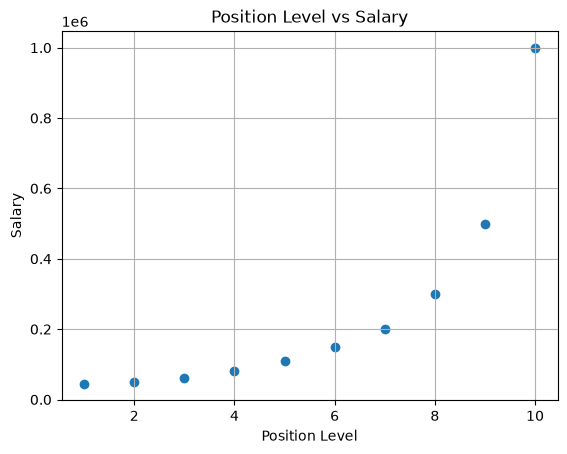

In [5]:
import matplotlib.pyplot as plt

plt.scatter(X, y)

plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.title("Position Level vs Salary")
plt.grid(True)

plt.show()

In [7]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

print("Linear Regression model trained successfully!")
print("Slope:", lin_reg.coef_[0])
print("Intercept:", lin_reg.intercept_)

Linear Regression model trained successfully!
Slope: 80878.78787878789
Intercept: -195333.33333333337


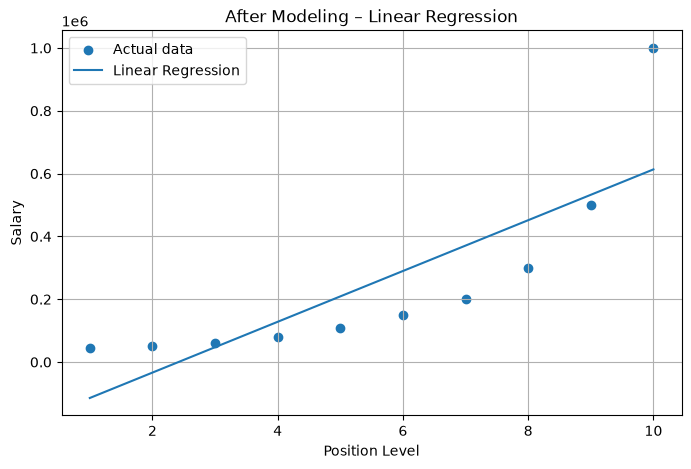

In [10]:
plt.figure(figsize=(8,5))

plt.scatter(X, y, label="Actual data")
plt.plot(X, lin_reg.predict(X), label="Linear Regression")

plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.title("After Modeling – Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
from sklearn.preprocessing import PolynomialFeatures

poly_reg = PolynomialFeatures(degree=4)
X_poly = poly_reg.fit_transform(X)

print("Original x:")
print(X[:3])
print("\nPolynomial features:")
print(X_poly[:3])

Original x:
[[1]
 [2]
 [3]]

Polynomial features:
[[ 1.  1.  1.  1.  1.]
 [ 1.  2.  4.  8. 16.]
 [ 1.  3.  9. 27. 81.]]


In [12]:
poly_model = LinearRegression()
poly_model.fit(X_poly, y)
print("Polynomial Regression model trained successfully!")

Polynomial Regression model trained successfully!


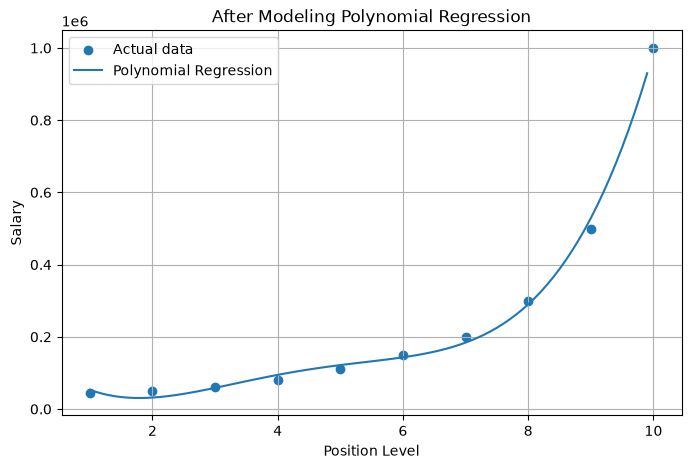

In [13]:
X_grid = np.arange(X.min(),X.max(), 0.1).reshape(-1,1)
y_grid_pred = poly_model.predict(poly_reg.transform(X_grid))

plt.figure(figsize=(8,5))
plt.scatter(X, y, label="Actual data")
plt.plot(X_grid, y_grid_pred, label="Polynomial Regression")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.title("After Modeling Polynomial Regression")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_linear = lin_reg.predict(X)
y_pred_poly = poly_model.predict(X_poly)

linear_mse = mean_squared_error(y, y_pred_linear)
linear_rmse = np.sqrt(linear_mse)
linear_mae = mean_absolute_error(y, y_pred_linear)
linear_r2 = r2_score(y, y_pred_linear)

poly_mse = mean_squared_error(y, y_pred_poly)
poly_rmse = np.sqrt(poly_mse)
poly_mae = mean_absolute_error(y, y_pred_poly)
poly_r2 = r2_score(y, y_pred_poly)

print("Linear Regression")
print("MSE :", linear_mse)
print("RMSE:", linear_rmse)
print("MAE :", linear_mae)
print("R2 :", linear_r2)

print("\nPolynomial Regression")
print("MSE :", poly_mse)
print("RMSE:", poly_rmse)
print("MAE :", poly_mae)
print("R2 :", poly_r2)

Linear Regression
MSE : 26695878787.878784
RMSE: 163388.73519272613
MAE : 128454.54545454546
R2 : 0.6690412331929895

Polynomial Regression
MSE : 210343822.84381685
RMSE: 14503.234909626777
MAE : 12681.818181828514
R2 : 0.9973922891706614


In [16]:
new_position = np.array([[6.5]])

linear_prediction = lin_reg.predict(new_position)[0]
polynomial_prediction = poly_model.predict(poly_reg.transform(new_position))[0]

print("Position Level:", new_position[0][0])
print("Linear Regression Prediction:", linear_prediction)
print("Polynomial Regression Prediction:",polynomial_prediction)

Position Level: 6.5
Linear Regression Prediction: 330378.78787878784
Polynomial Regression Prediction: 158862.45265155006
